In [2]:
# !pip install librosa tslearn stumpy matplotlib
import os
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from tslearn.preprocessing import TimeSeriesScalerMinMax, TimeSeriesResampler
from tslearn.clustering import TimeSeriesKMeans
from tslearn.shapelets import LearningShapelets
import stumpy # Per Motif e Anomalies

d:\Anaconda\envs\mining_env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
data = 'dataset/df_fedez_fibra.csv'
index_col = 0
df = pd.read_csv(data, sep=',', index_col=index_col)

pd.set_option('display.max_columns', None)

In [4]:
# Trasforma l'indice in colonna e rinominala
df = df.reset_index().rename(columns={'index': 'track_id'})

In [5]:
AUDIO_COLS = [
    # Audio/Acoustic Features (Using a representative sample)
    'bpm', 'centroid', 'flux', 'rms', 'spectral_complexity', 'pitch', 'flatness', 'duration_ms'
]

## Find the most similar tracks based on the audio features values that we already have from previous phases

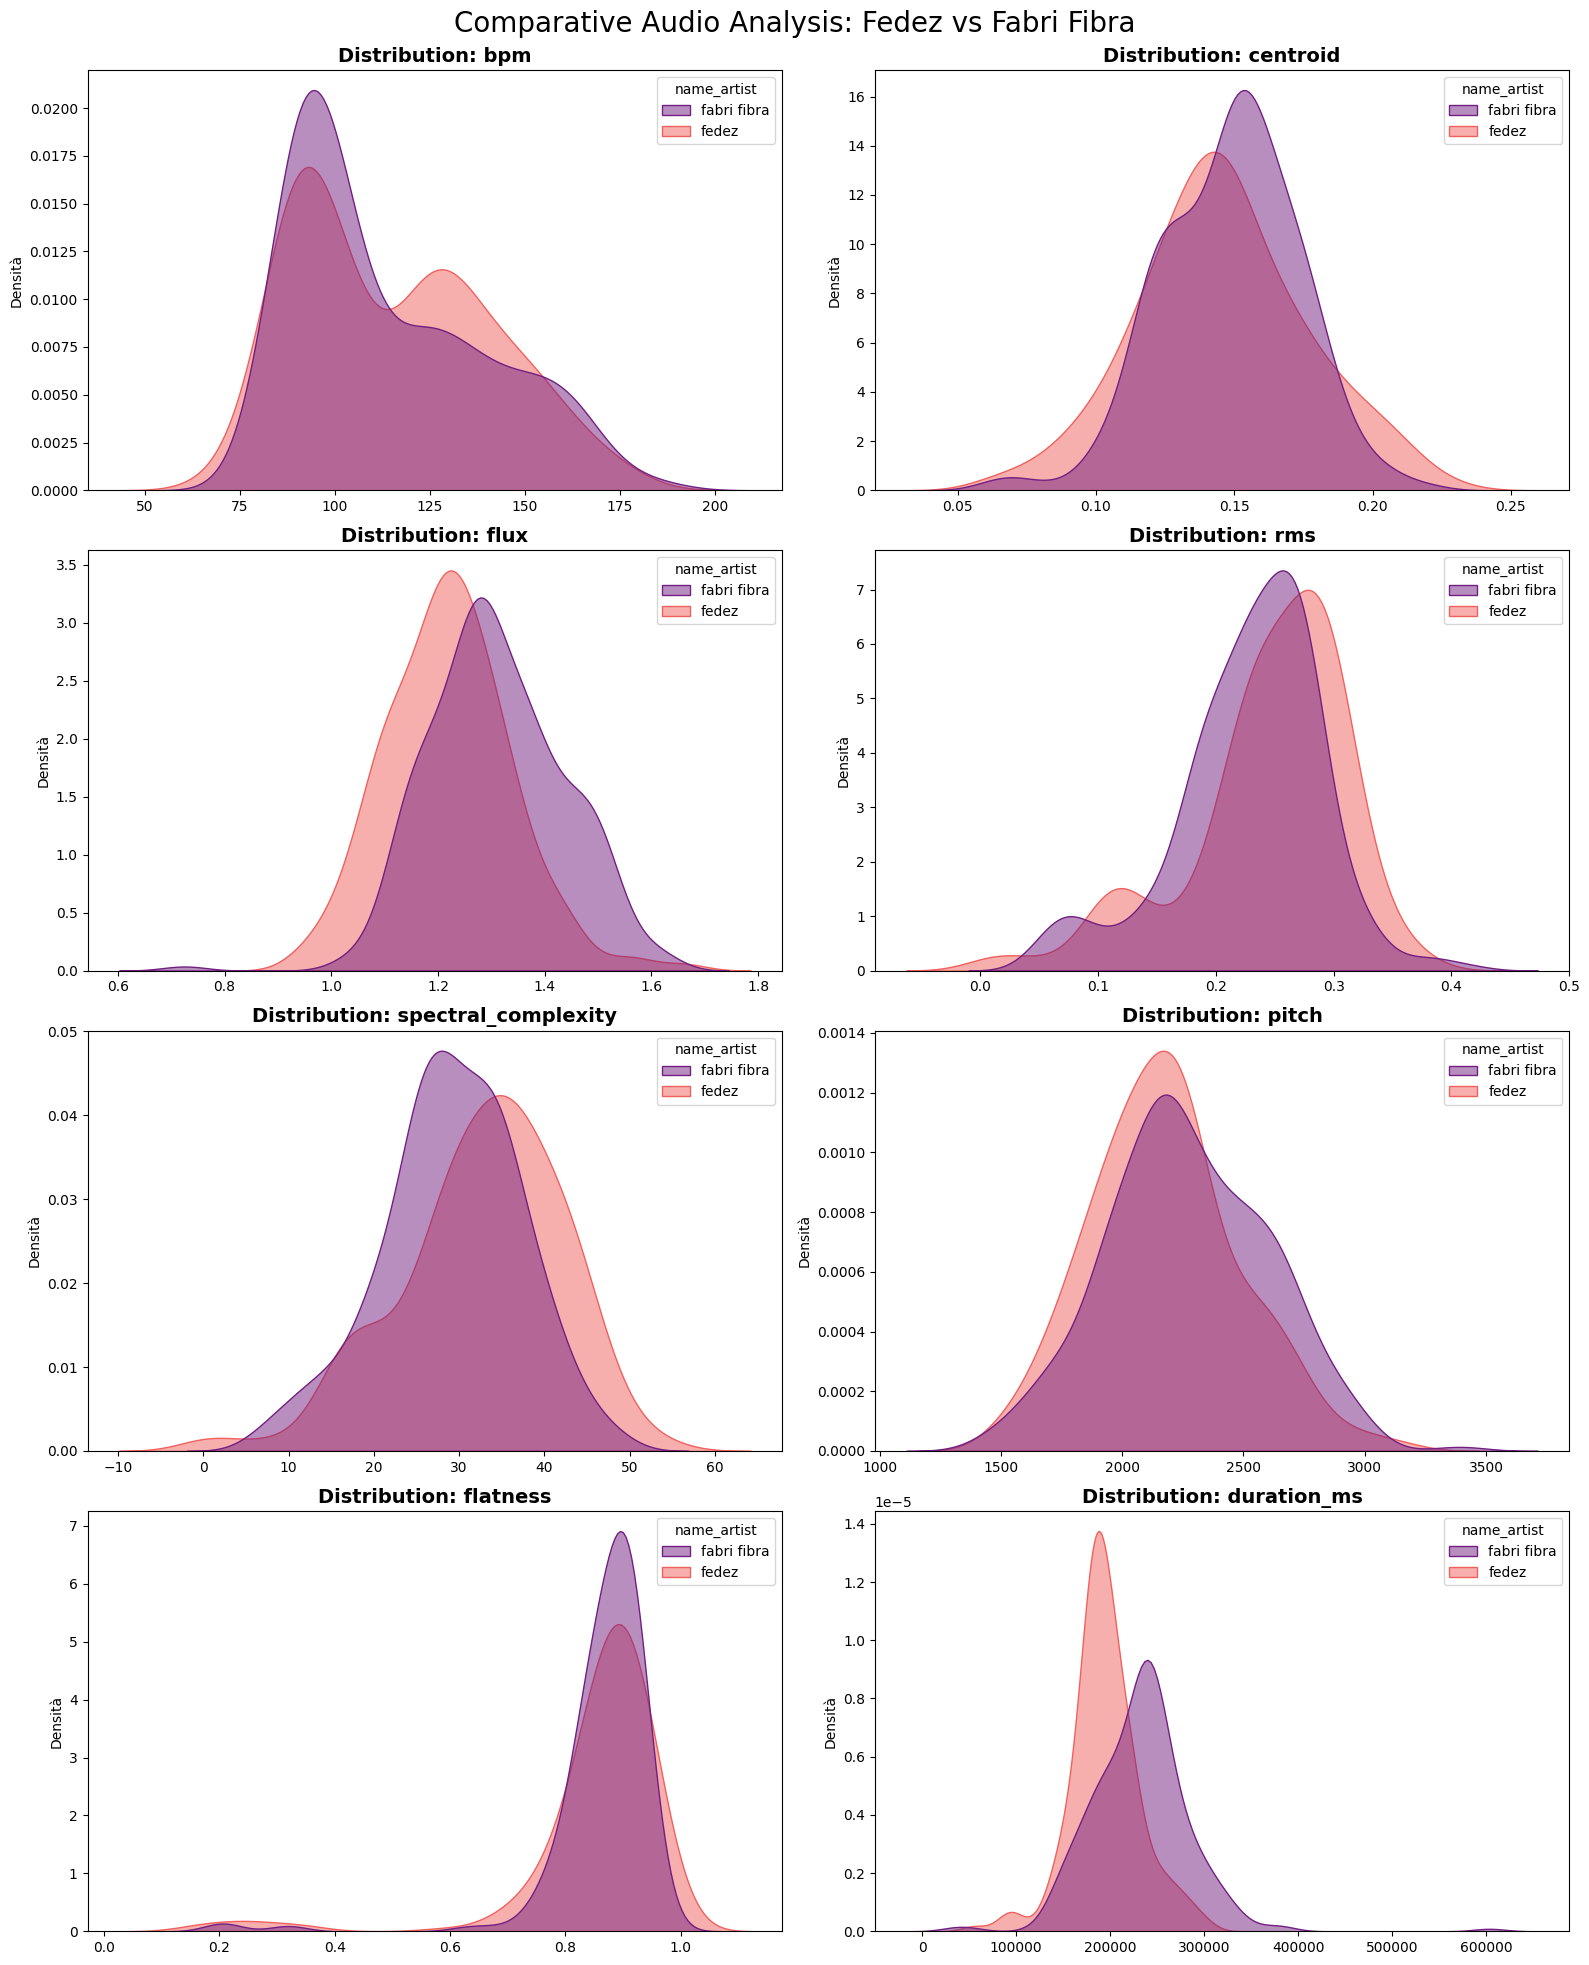

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pulizia rapida per essere sicuri che i grafici non siano vuoti
# Trasforma in numeri (se c'è testo diventano NaN) e rimuove i NaN per il plot
df_clean = df.copy()
for col in AUDIO_COLS:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
df_clean = df_clean.dropna(subset=AUDIO_COLS)

# 2. Creazione della griglia di grafici di distribuzione (KDE)
# Creiamo una griglia 4x2 (visto che hai 8 feature)
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten() # Trasforma la matrice di assi in una lista piatta

for i, col in enumerate(AUDIO_COLS):
    sns.kdeplot(
        data=df_clean, 
        x=col, 
        hue='name_artist', 
        fill=True, 
        ax=axes[i], 
        palette='magma', # Colori decisi (es. viola e arancio)
        alpha=0.5, 
        common_norm=False
    )
    axes[i].set_title(f'Distribution: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Densità')

# 3. Pulizia estetica
plt.tight_layout()
plt.subplots_adjust(top=0.95)
fig.suptitle('Comparative Audio Analysis: Fedez vs Fabri Fibra', fontsize=20)
plt.show()

In [68]:
best_matches = top_cross_matches.drop_duplicates(subset=['song_1'])
print(best_matches[['song_1', 'artist_1', 'song_2', 'artist_2', 'score']])

                         song_1     artist_1                 song_2 artist_2  \
72863          Tutti In Campana  fabri fibra  Voglio averti account    fedez   
9615             Fatti Da Parte  fabri fibra                 Record    fedez   
57964                 Tony Hawk  fabri fibra     La Mia Generazione    fedez   
25289          Pronti Al Peggio  fabri fibra       Sfregi e difetti    fedez   
76878       Il Mio Amico Arnold  fabri fibra             Viva l’IVA    fedez   
...                         ...          ...                    ...      ...   
77168   Fabri Fibra A Spit 2011  fabri fibra     Milano Bene (2008)    fedez   
40339            Incomprensioni  fabri fibra               Avvoltoi    fedez   
19384         Dalla A Alla Zeta  fabri fibra               Avvoltoi    fedez   
17720            Mal Di Stomaco  fabri fibra               BANCOMAT    fedez   
84443  Freestyle a Radio Deejay  fabri fibra                  SUSHI    fedez   

          score  
72863  0.999308  
961

## Analyzing similarity matrix from mp3 files

In [7]:
# Configurazione mappatura
ARTIST_MAP = {
    "ART07024718": 0, # Fedez
    "ART25707984": 1  # Fabri Fibra
}

def load_audio_dataset(folder_path, duration=30):
    features = []
    labels = []
    file_names = []
    
    files = [f for f in os.listdir(folder_path) if f.endswith(".mp3")]
    print(f"File totali trovati: {len(files)}") # Debug

    for file in files:
        # Cerchiamo se uno dei codici artista è contenuto nel nome del file
        label = None
        for code, l_id in ARTIST_MAP.items():
            if code.upper() in file.upper(): # Case-insensitive
                label = l_id
                break
        
        if label is not None:
            path = os.path.join(folder_path, file)
            try:
                # Carichiamo l'audio
                y, sr = librosa.load(path, duration=duration, offset=30)
                # Feature extraction
                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
                features.append(mfcc.T)
                labels.append(label)
                file_names.append(file)
            except Exception as e:
                print(f"Errore nel caricamento di {file}: {e}")
    
    if len(features) == 0:
        raise ValueError("Nessun file caricato! Controlla i codici ARTIST_MAP e il percorso cartella.")
        
    return features, np.array(labels), file_names

# Riesegui il caricamento
X_raw, y_true, names = load_audio_dataset("dataset/fedez_fibra")
X_resampled = TimeSeriesResampler(sz=500).fit_transform(X_raw)
X_final = TimeSeriesScalerMinMax().fit_transform(X_resampled)
print(f"Dataset caricato correttamente: {X_final.shape}")

File totali trovati: 454


d:\Anaconda\envs\mining_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


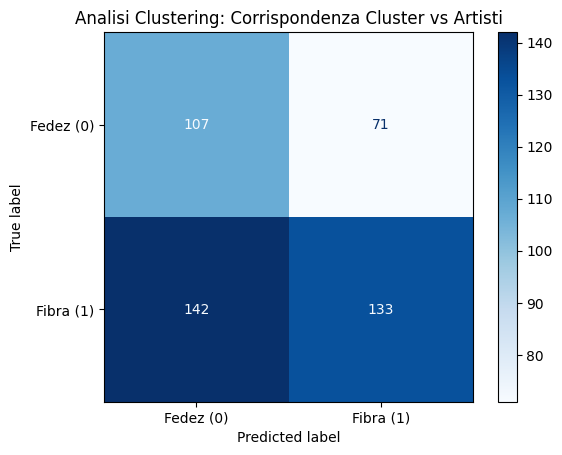

In [8]:
from tslearn.clustering import TimeSeriesKMeans
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Applichiamo il Clustering (n_clusters=2 per Fedez e Fibra)
# Usiamo DTW come metrica per allineare i pattern audio
km = TimeSeriesKMeans(n_clusters=2, metric="dtw", max_iter=5, random_state=42, n_jobs=-1)
y_pred = km.fit_predict(X_final)

# Visualizzazione della Matrice di Confusione
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fedez (0)", "Fibra (1)"])
disp.plot(cmap="Blues")
plt.title("Analisi Clustering: Corrispondenza Cluster vs Artisti")
plt.show()

In [43]:
# 1. Errori: Fibra scambiato per Fedez (quelli che avevi già)
idx_fibra_as_fedez = np.where((y_true == 1) & (y_pred == 0))[0]
codes_fibra_as_fedez = [names[i].split(' - ')[-1].replace('.mp3', '') for i in idx_fibra_as_fedez]

# 2. Errori: Fedez scambiato per Fibra (le 71 canzoni "dimenticate")
idx_fedez_as_fibra = np.where((y_true == 0) & (y_pred == 1))[0]
codes_fedez_as_fibra = [names[i].split(' - ')[-1].replace('.mp3', '') for i in idx_fedez_as_fibra]

# 3. Uniamo tutto per avere la lista completa degli errori
error_tr_codes = codes_fibra_as_fedez + codes_fedez_as_fibra

print(f"Errori Fibra -> Fedez: {len(codes_fibra_as_fedez)}")
print(f"Errori Fedez -> Fibra: {len(codes_fedez_as_fibra)}")

Errori Fibra -> Fedez: 142
Errori Fedez -> Fibra: 71


In [44]:
# 1. Normalizzazione (Fondamentale per cosine_similarity)
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

scaler = MinMaxScaler()
df_audio = df[AUDIO_COLS].apply(pd.to_numeric, errors='coerce').fillna(0)
features_scaled = scaler.fit_transform(df_audio)

# 2. Calcolo della matrice (QUATTRO RIGHE FONDAMENTALI)
# Assicurati di chiamarla esattamente sim_matrix
sim_matrix = cosine_similarity(features_scaled)

# 3. Trasformazione della matrice in un DataFrame "leggibile" con track_id
simili_list = []
titles = df['title'].values
artists = df['name_artist'].values
track_ids = df['track_id'].values 

for i in range(len(titles)):
    for j in range(i + 1, len(titles)):
        simili_list.append({
            'id_1': track_ids[i],     # Aggiungiamo l'ID della prima canzone
            'song_1': titles[i],
            'artist_1': artists[i],
            'id_2': track_ids[j],     # Aggiungiamo l'ID della seconda canzone
            'song_2': titles[j],
            'artist_2': artists[j],
            'score': sim_matrix[i, j]
        })

# Creiamo il DataFrame locale
df_similar = pd.DataFrame(simili_list).sort_values(by='score', ascending=False)

# 4. Filtriamo le canzoni "cross-artist"
df_cross = df_similar[df_similar['artist_1'] != df_similar['artist_2']].copy()

print("Top 10 highest similarity cross-artist tracks (con IDs):")
# Visualizziamo anche le colonne id_1 e id_2
print(df_cross[['id_1', 'song_1', 'id_2', 'song_2', 'score']].head(10))

Top 10 highest similarity cross-artist tracks (con IDs):
           id_1                         song_1      id_2  \
72863  TR975085               Tutti In Campana  TR490859   
9615   TR239743                 Fatti Da Parte  TR731379   
57964  TR700280                      Tony Hawk  TR953399   
25289  TR412854               Pronti Al Peggio  TR701532   
76878  TR955916            Il Mio Amico Arnold  TR816395   
78578  TR946363                       Vado Via  TR356306   
70628  TR166646  Chi Vuole Essere Fabri Fibra?  TR246839   
6512   TR772758                    Rap in vena  TR229227   
49678  TR220174               Spara Al Diavolo  TR229227   
25243  TR412854               Pronti Al Peggio  TR854907   

                                song_2     score  
72863            Voglio averti account  0.999308  
9615                            Record  0.998355  
57964               La Mia Generazione  0.998040  
25289                 Sfregi e difetti  0.997883  
76878                      

In [45]:
df_cross_artist = df_similar[df_similar['artist_1'] != df_similar['artist_2']].copy()

# 2. Filtriamo per alta similarità (es. > 0.98)
top_cross_matches = df_cross_artist[df_cross_artist['score'] > 0.98].sort_values(by='score', ascending=False)

best_matches = top_cross_matches.drop_duplicates(subset=['song_1'])
print(best_matches[['song_1', 'artist_1', 'song_2', 'artist_2', 'score']])

                         song_1     artist_1                 song_2 artist_2  \
72863          Tutti In Campana  fabri fibra  Voglio averti account    fedez   
9615             Fatti Da Parte  fabri fibra                 Record    fedez   
57964                 Tony Hawk  fabri fibra     La Mia Generazione    fedez   
25289          Pronti Al Peggio  fabri fibra       Sfregi e difetti    fedez   
76878       Il Mio Amico Arnold  fabri fibra             Viva l’IVA    fedez   
...                         ...          ...                    ...      ...   
77168   Fabri Fibra A Spit 2011  fabri fibra     Milano Bene (2008)    fedez   
40339            Incomprensioni  fabri fibra               Avvoltoi    fedez   
19384         Dalla A Alla Zeta  fabri fibra               Avvoltoi    fedez   
17720            Mal Di Stomaco  fabri fibra               BANCOMAT    fedez   
84443  Freestyle a Radio Deejay  fabri fibra                  SUSHI    fedez   

          score  
72863  0.999308  
961

In [47]:
# 1. Filtra direttamente usando i track_id degli errori
# Cerchiamo nei best_matches (o df_cross) dove id_1 o id_2 sono nella tua lista nera
errori_con_simile = best_matches[
    (best_matches['id_1'].isin(error_tr_codes)) | 
    (best_matches['id_2'].isin(error_tr_codes))
]

# 2. Risultato immediato
print(f"Errori 'giustificati' (match > 0.98 con l'altro artista): {len(errori_con_simile)}")
print(errori_con_simile[['id_1', 'song_1', 'id_2', 'song_2', 'score']])

Errori 'giustificati' (match > 0.98 con l'altro artista): 186
           id_1                         song_1      id_2  \
9615   TR239743                 Fatti Da Parte  TR731379   
25289  TR412854               Pronti Al Peggio  TR701532   
78578  TR946363                       Vado Via  TR356306   
70628  TR166646  Chi Vuole Essere Fabri Fibra?  TR246839   
6512   TR772758                    Rap in vena  TR229227   
...         ...                            ...       ...   
69355  TR484122                    Nella Scena  TR636326   
12720  TR613459             Applausi Per Fibra  TR606252   
84251  TR192986               Freestyle (2004)  TR680926   
40339  TR168277                 Incomprensioni  TR606252   
84443  TR739987       Freestyle a Radio Deejay  TR680926   

                                song_2     score  
9615                            Record  0.998355  
25289                 Sfregi e difetti  0.997883  
78578                    LA DOLCE VITA  0.997787  
70628        

In [48]:
# 1. Identifichiamo i 10 ID degli errori "puri" (quelli senza match cross-artist > 0.98)
# error_tr_codes contiene i 142 ID totali degli errori
# errori_con_simile contiene i 132 ID giustificati (usiamo id_1 o id_2 a seconda di quale era l'errore)
ids_giustificati = set(errori_con_simile['id_1'].tolist() + errori_con_simile['id_2'].tolist())
errori_puri_ids = [idx for idx in error_tr_codes if idx not in ids_giustificati]

# 2. Creiamo il DataFrame degli errori puri per l'analisi delle feature
df_errori_puri = df[df['track_id'].isin(errori_puri_ids)][['track_id', 'title', 'name_artist'] + AUDIO_COLS]

# 3. Vediamo la loro massima somiglianza (anche interna) per capire con cosa si confondono
max_sim_puri = df_similar[
    (df_similar['id_1'].isin(errori_puri_ids)) | 
    (df_similar['id_2'].isin(errori_puri_ids))
].sort_values(by='score', ascending=False).drop_duplicates(subset=['id_1'])

print(f"Analisi dei {len(errori_puri_ids)} errori 'puri' (senza match cross-artist estremi):")
print(max_sim_puri[['id_1', 'song_1', 'id_2', 'song_2', 'artist_1', 'artist_2', 'score']].head(10))

Analisi dei 48 errori 'puri' (senza match cross-artist estremi):
           id_1             song_1      id_2  \
89016  TR854907            BATTITO  TR731379   
98592  TR485842        Lo zainetto  TR411730   
92990  TR196675           VITTORIA  TR572044   
96461  TR498962      Single a vita  TR413349   
25243  TR412854   Pronti Al Peggio  TR854907   
96088  TR608745  L’una per l’alcol  TR828726   
57884  TR700280          Tony Hawk  TR943904   
88643  TR203683              MILLE  TR731111   
98086  TR377739             M.I.A.  TR128449   
97883  TR770885         3 di notte  TR943904   

                                                  song_2     artist_1  \
89016                                             Record        fedez   
98592                                         Ipocondria        fedez   
92990                                    LEGGERI LEGGERI        fedez   
96461                                Liberi in cattività        fedez   
25243                                    

## Motif and anomalies analysis

d:\Anaconda\envs\mining_env\Lib\site-packages\stumpy\core.py:3703: UserWarning: Arrays T_A, T_B are not equal, which implies an AB-join. `ignore_trivial` has been automatically set to `False`.
  warnings.warn(msg)


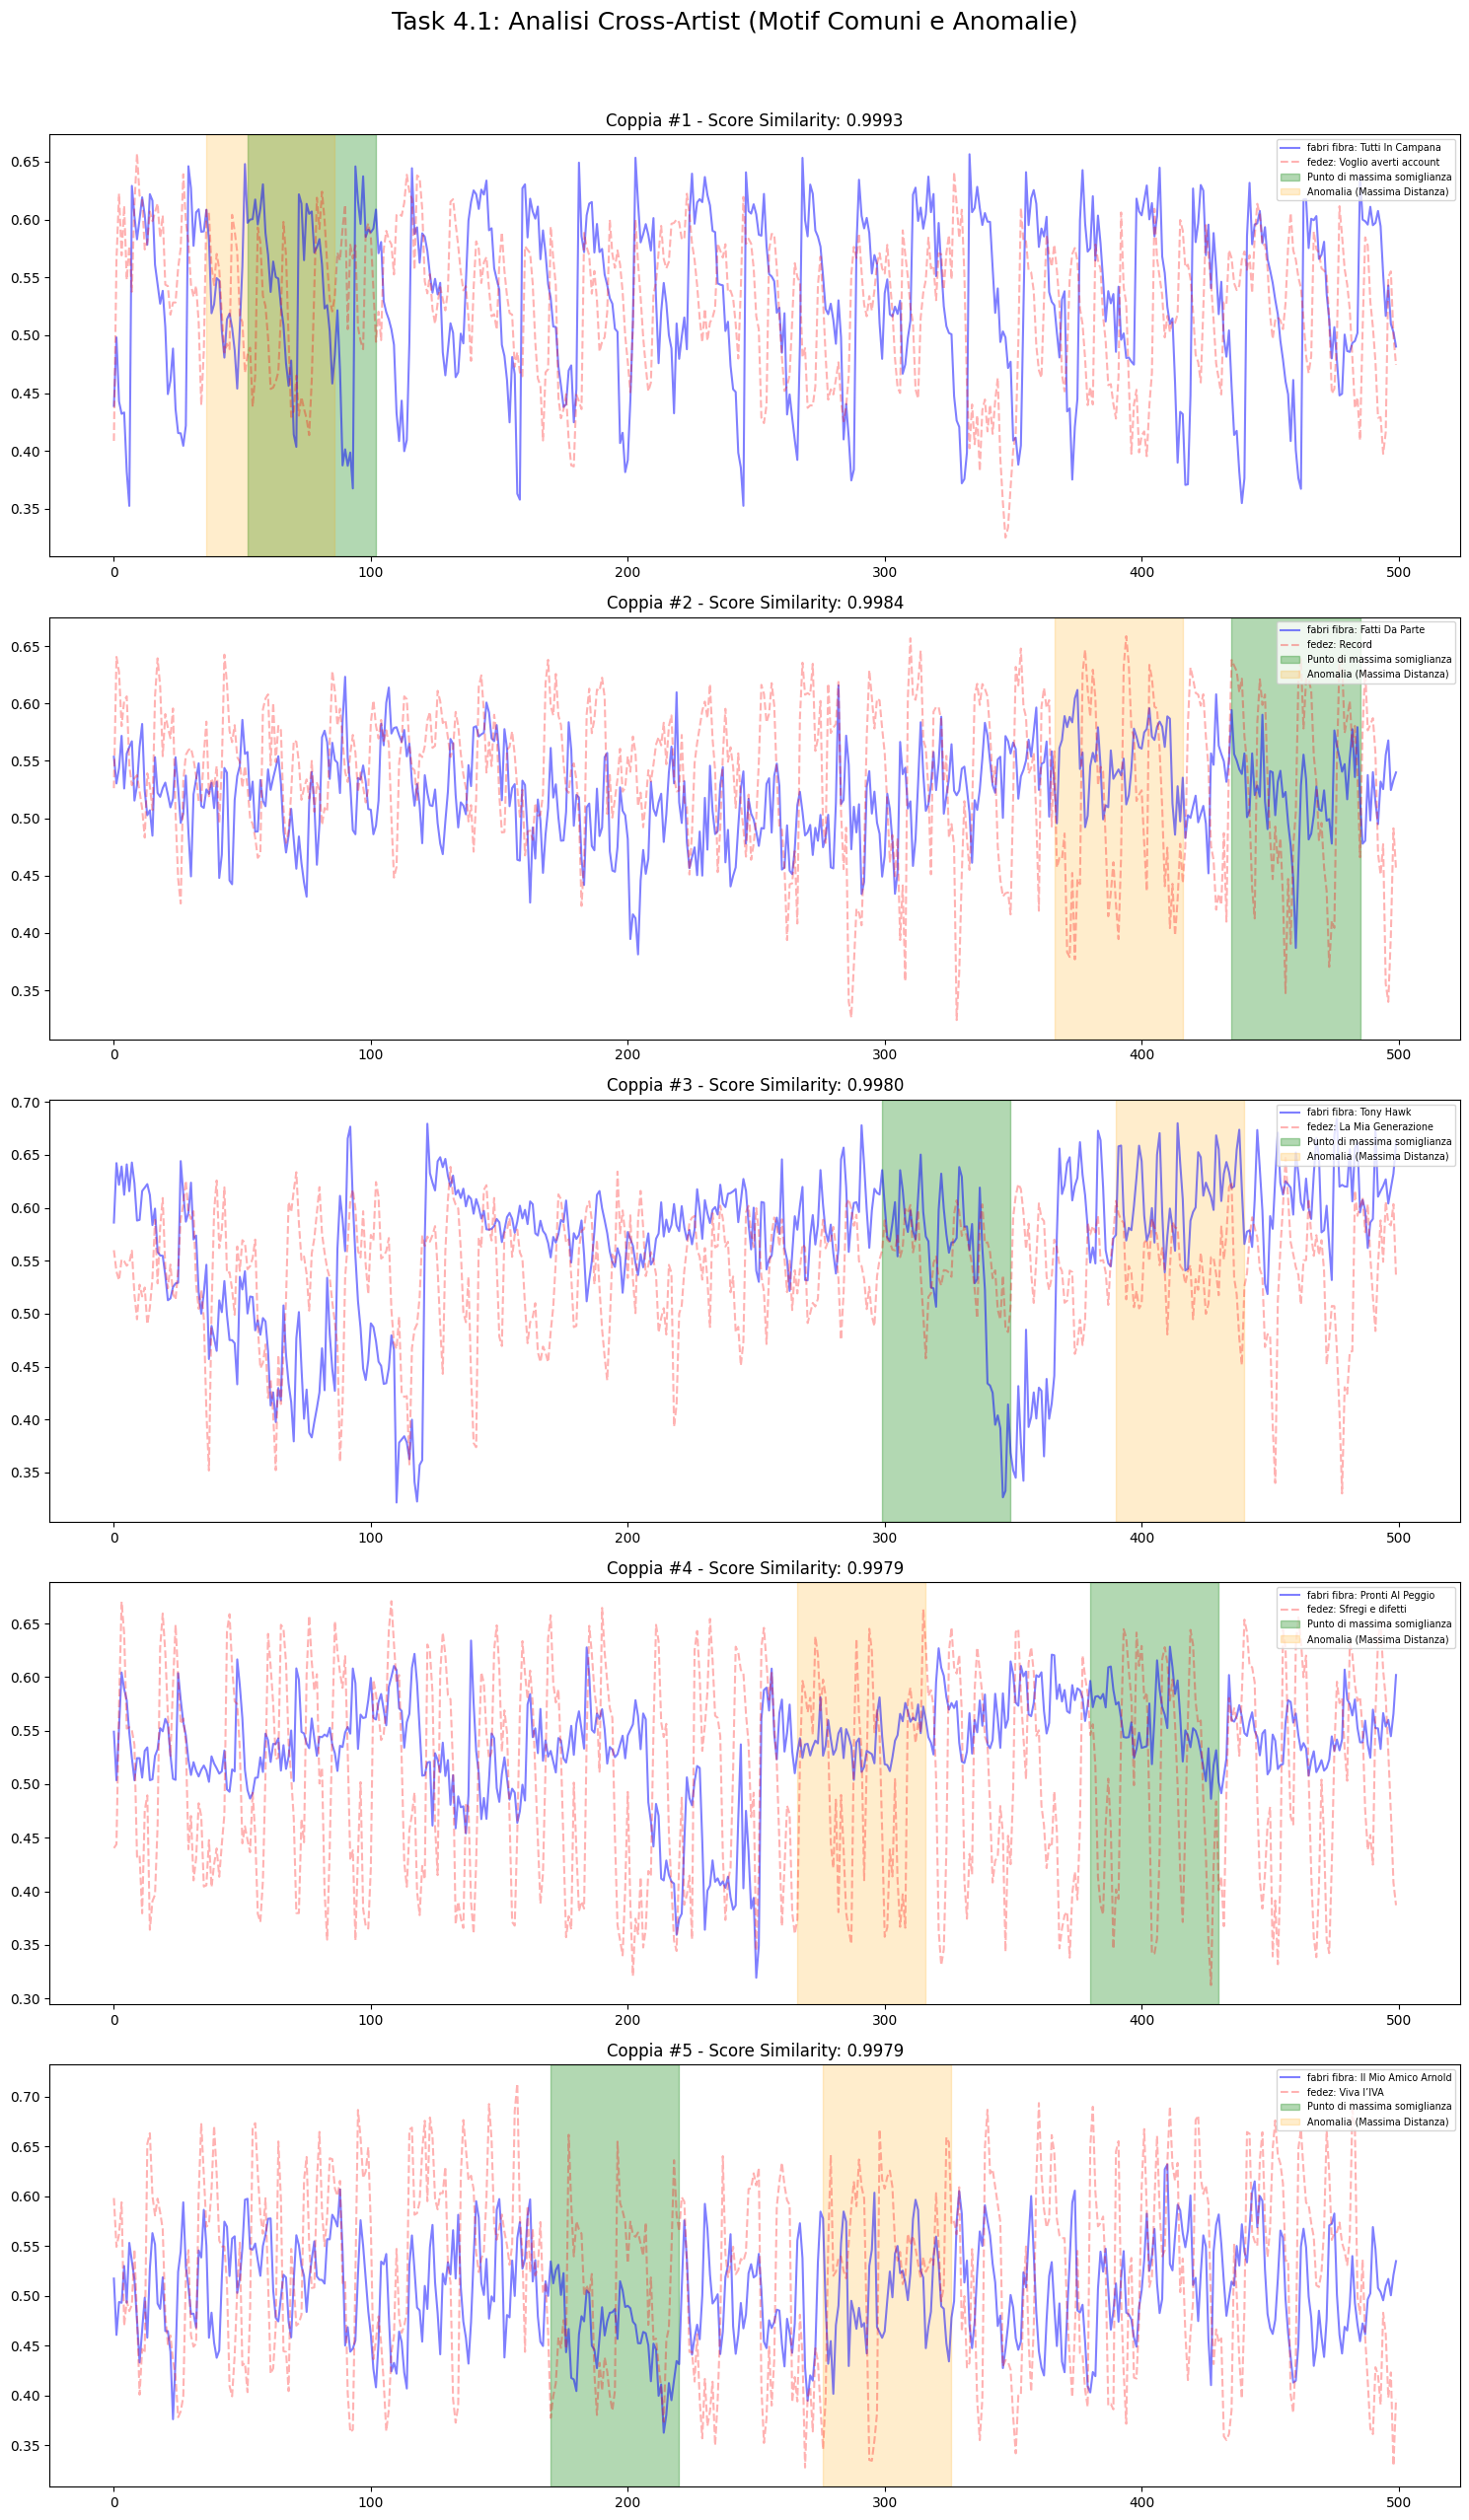

In [49]:
import stumpy
import numpy as np
import matplotlib.pyplot as plt

m = 50 # Finestra di circa 2 secondi

fig, axes = plt.subplots(5, 1, figsize=(15, 25))
fig.suptitle('Task 4.1: Analisi Cross-Artist (Motif Comuni e Anomalie)', fontsize=18, y=1.02)

for i, (index, row) in enumerate(best_matches.head(5).iterrows()):
    # 1. Recupero indici e dati
    idx_a = np.where(df['track_id'].values == row['id_1'])[0][0]
    idx_b = np.where(df['track_id'].values == row['id_2'])[0][0]
    
    # Usiamo la media degli MFCC per avere una visione d'insieme del timbro
    s_a = X_final[idx_a, :, :].mean(axis=1).flatten().astype(float)
    s_b = X_final[idx_b, :, :].mean(axis=1).flatten().astype(float)
    
    # 2. CROSS-MOTIF (Il vero confronto)
    # Cerchiamo i segmenti di s_a che esistono anche in s_b
    comp_mp = stumpy.stump(s_a, m=m, T_B=s_b)
    idx_a_motif = np.argmin(comp_mp[:, 0]) # Dove inizia in Fedez
    idx_b_motif = comp_mp[idx_a_motif, 1]  # Dove inizia il suo sosia in Fibra
    
    # 3. ANOMALIE (Internal Discord)
    # Qui cerchiamo il punto più "strano" di Fedez che NON somiglia a Fibra
    idx_a_discord = np.argmax(comp_mp[:, 0])
    
    ax = axes[i]
    ax.plot(s_a, label=f"{row['artist_1']}: {row['song_1']}", color='blue', alpha=0.5)
    ax.plot(s_b, label=f"{row['artist_2']}: {row['song_2']}", color='red', linestyle='--', alpha=0.3)
    
    # EVIDENZIAZIONE MOTIF COMUNE (Verde)
    # Questo è il pezzetto dove i due brani sono più simili tra loro
    ax.axvspan(idx_a_motif, idx_a_motif + m, color='green', alpha=0.3, label='Punto di massima somiglianza')
    
    # EVIDENZIAZIONE ANOMALIA (Giallo)
    # Questo è il punto dove Fedez è più diverso da Fibra
    ax.axvspan(idx_a_discord, idx_a_discord + m, color='orange', alpha=0.2, label='Anomalia (Massima Distanza)')
    
    ax.set_title(f"Coppia #{i+1} - Score Similarity: {row['score']:.4f}")
    ax.legend(loc='upper right', fontsize='x-small')

plt.tight_layout()
plt.show()

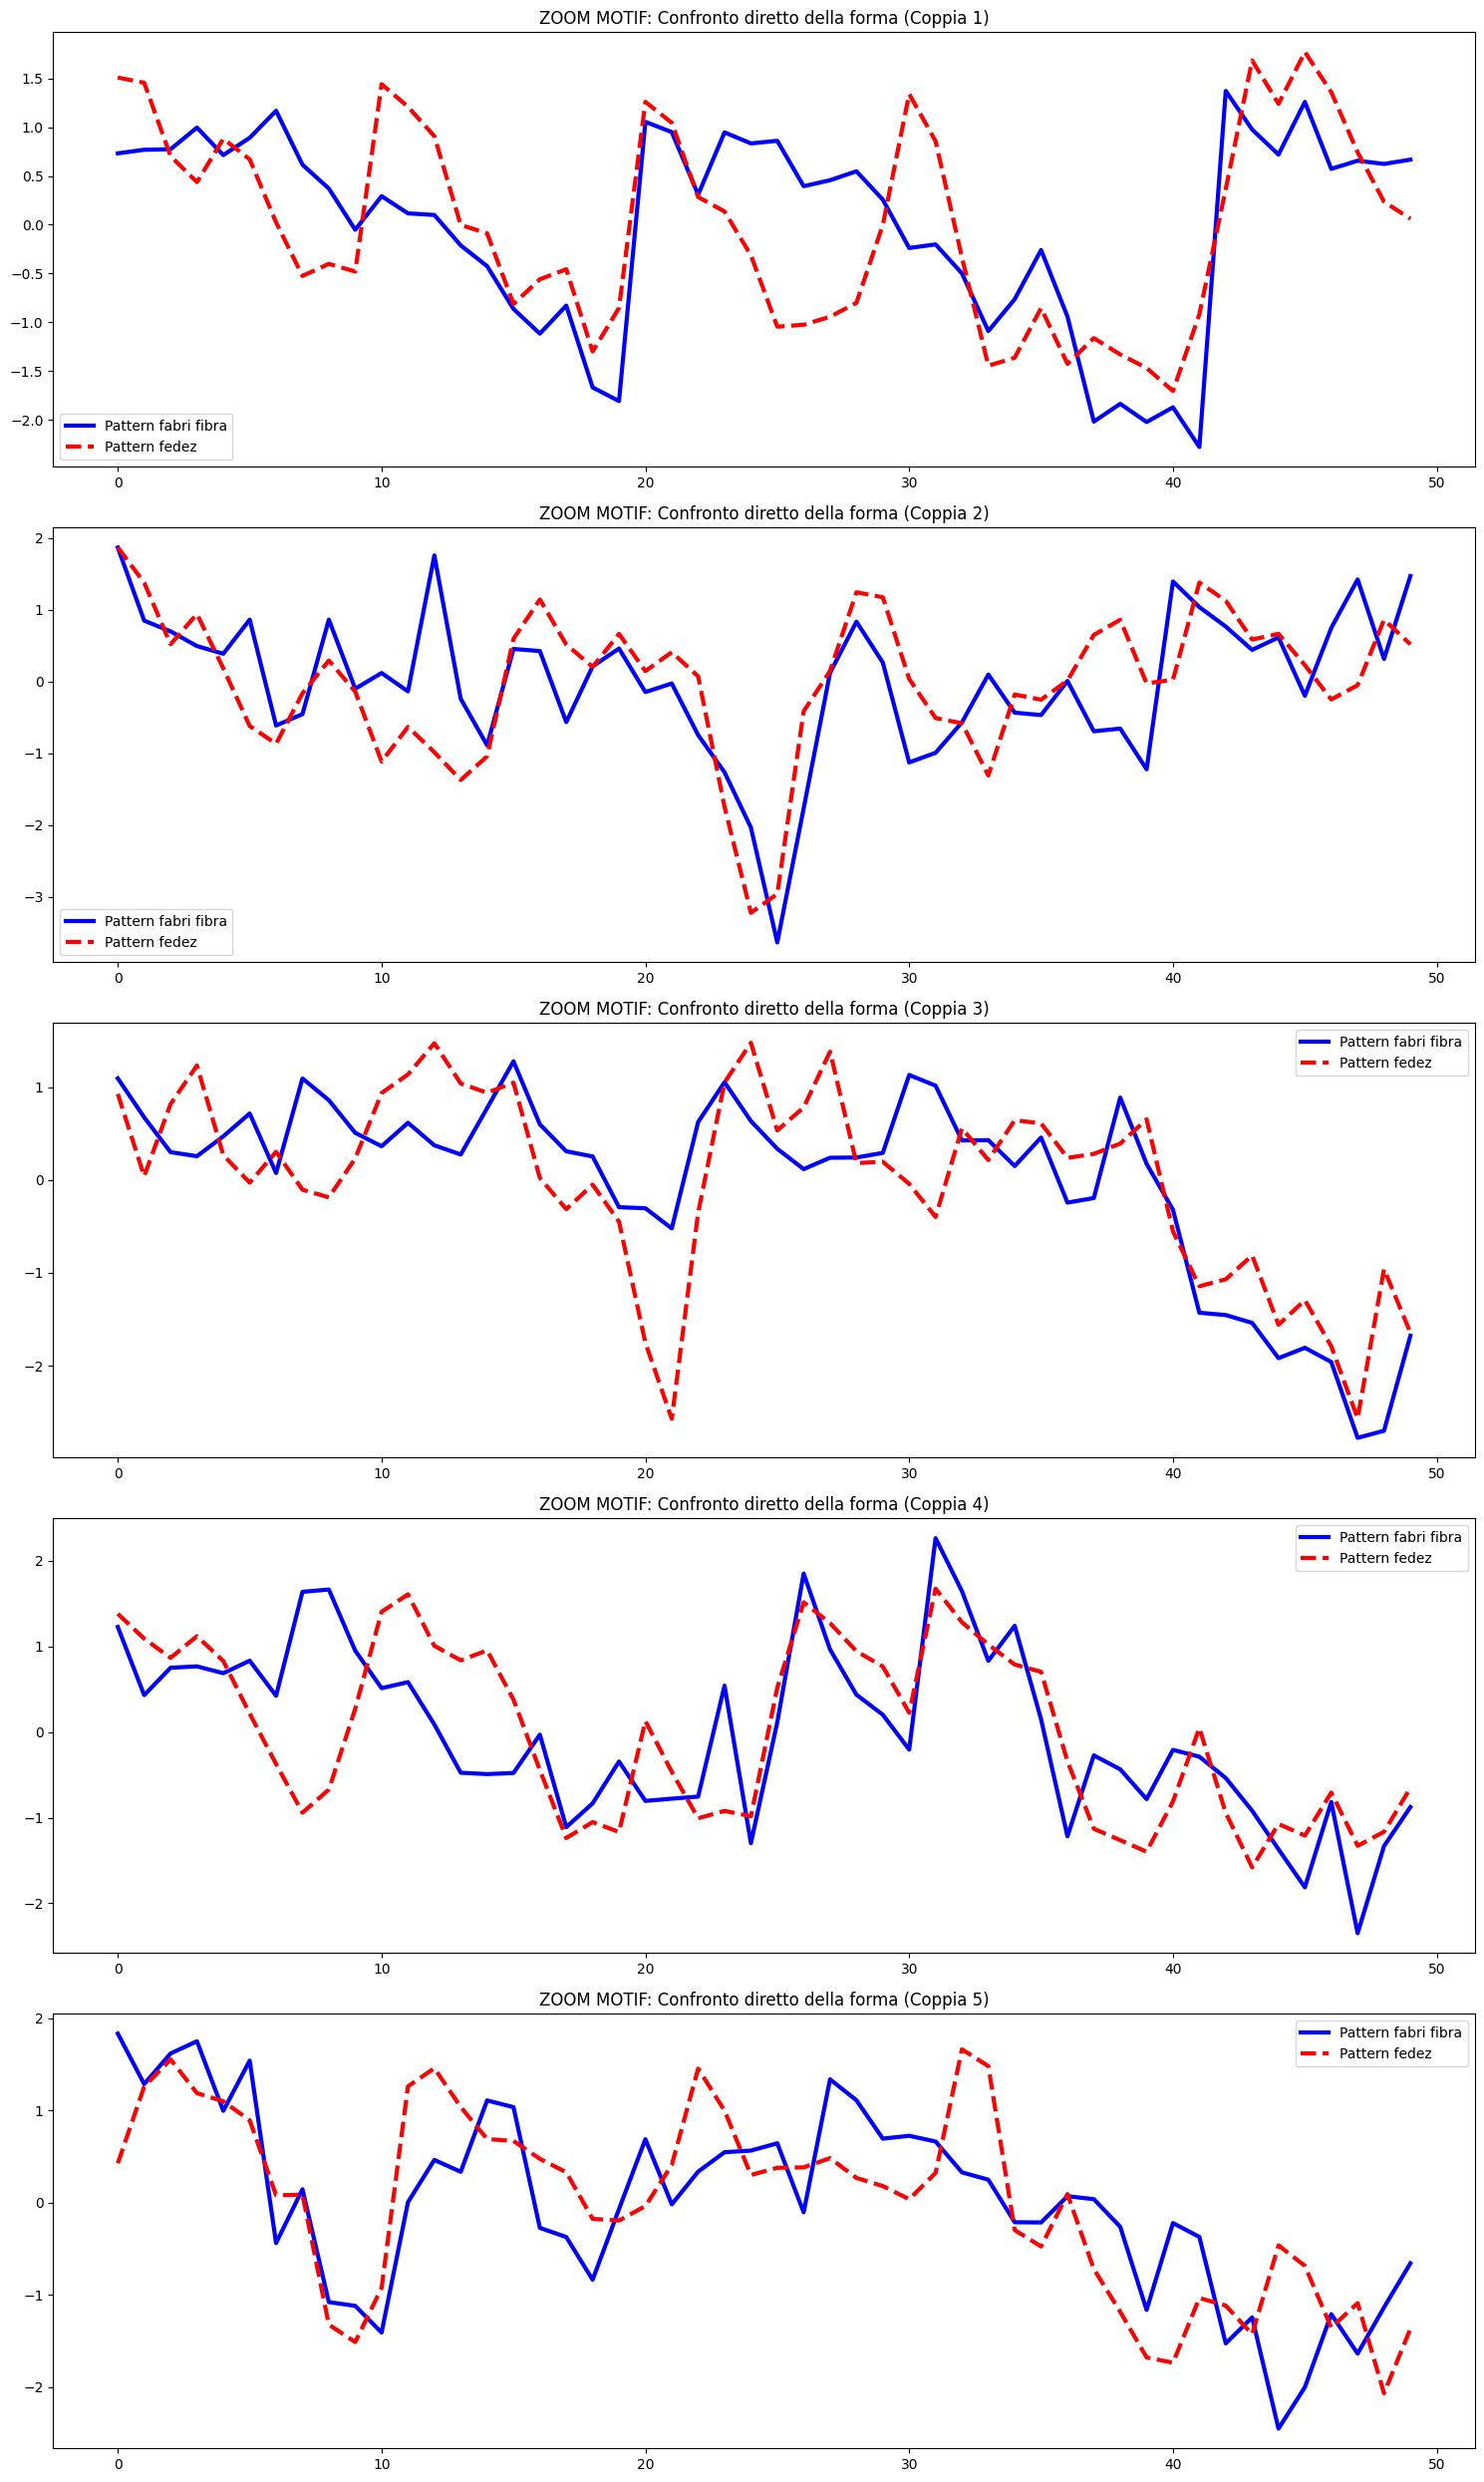

In [50]:
import stumpy

m = 50 
fig, axes = plt.subplots(5, 1, figsize=(15, 25))

for i, (index, row) in enumerate(df_cross.head(5).iterrows()):
    idx_a = np.where(df['track_id'].values == row['id_1'])[0][0]
    idx_b = np.where(df['track_id'].values == row['id_2'])[0][0]
    
    # Serie temporali
    s_a = X_final[idx_a, :, :].mean(axis=1).flatten().astype(float)
    s_b = X_final[idx_b, :, :].mean(axis=1).flatten().astype(float)
    
    # Cerchiamo il match migliore tra le due (Join)
    comp_mp = stumpy.stump(s_a, m=m, T_B=s_b)
    idx_a_motif = np.argmin(comp_mp[:, 0])
    idx_b_motif = comp_mp[idx_a_motif, 1]
    
    # Estraiamo i due segmenti
    segment_a = s_a[idx_a_motif : idx_a_motif + m]
    segment_b = s_b[idx_b_motif : idx_b_motif + m]
    
    # Normalizziamo i segmenti per confrontare solo la FORMA
    segment_a = (segment_a - np.mean(segment_a)) / np.std(segment_a)
    segment_b = (segment_b - np.mean(segment_b)) / np.std(segment_b)
    
    ax = axes[i]
    ax.plot(segment_a, label=f"Pattern {row['artist_1']}", lw=3, color='blue')
    ax.plot(segment_b, label=f"Pattern {row['artist_2']}", lw=3, color='red', linestyle='--')
    ax.set_title(f"ZOOM MOTIF: Confronto diretto della forma (Coppia {i+1})")
    ax.legend()

plt.tight_layout()
plt.show()

### Anomalies

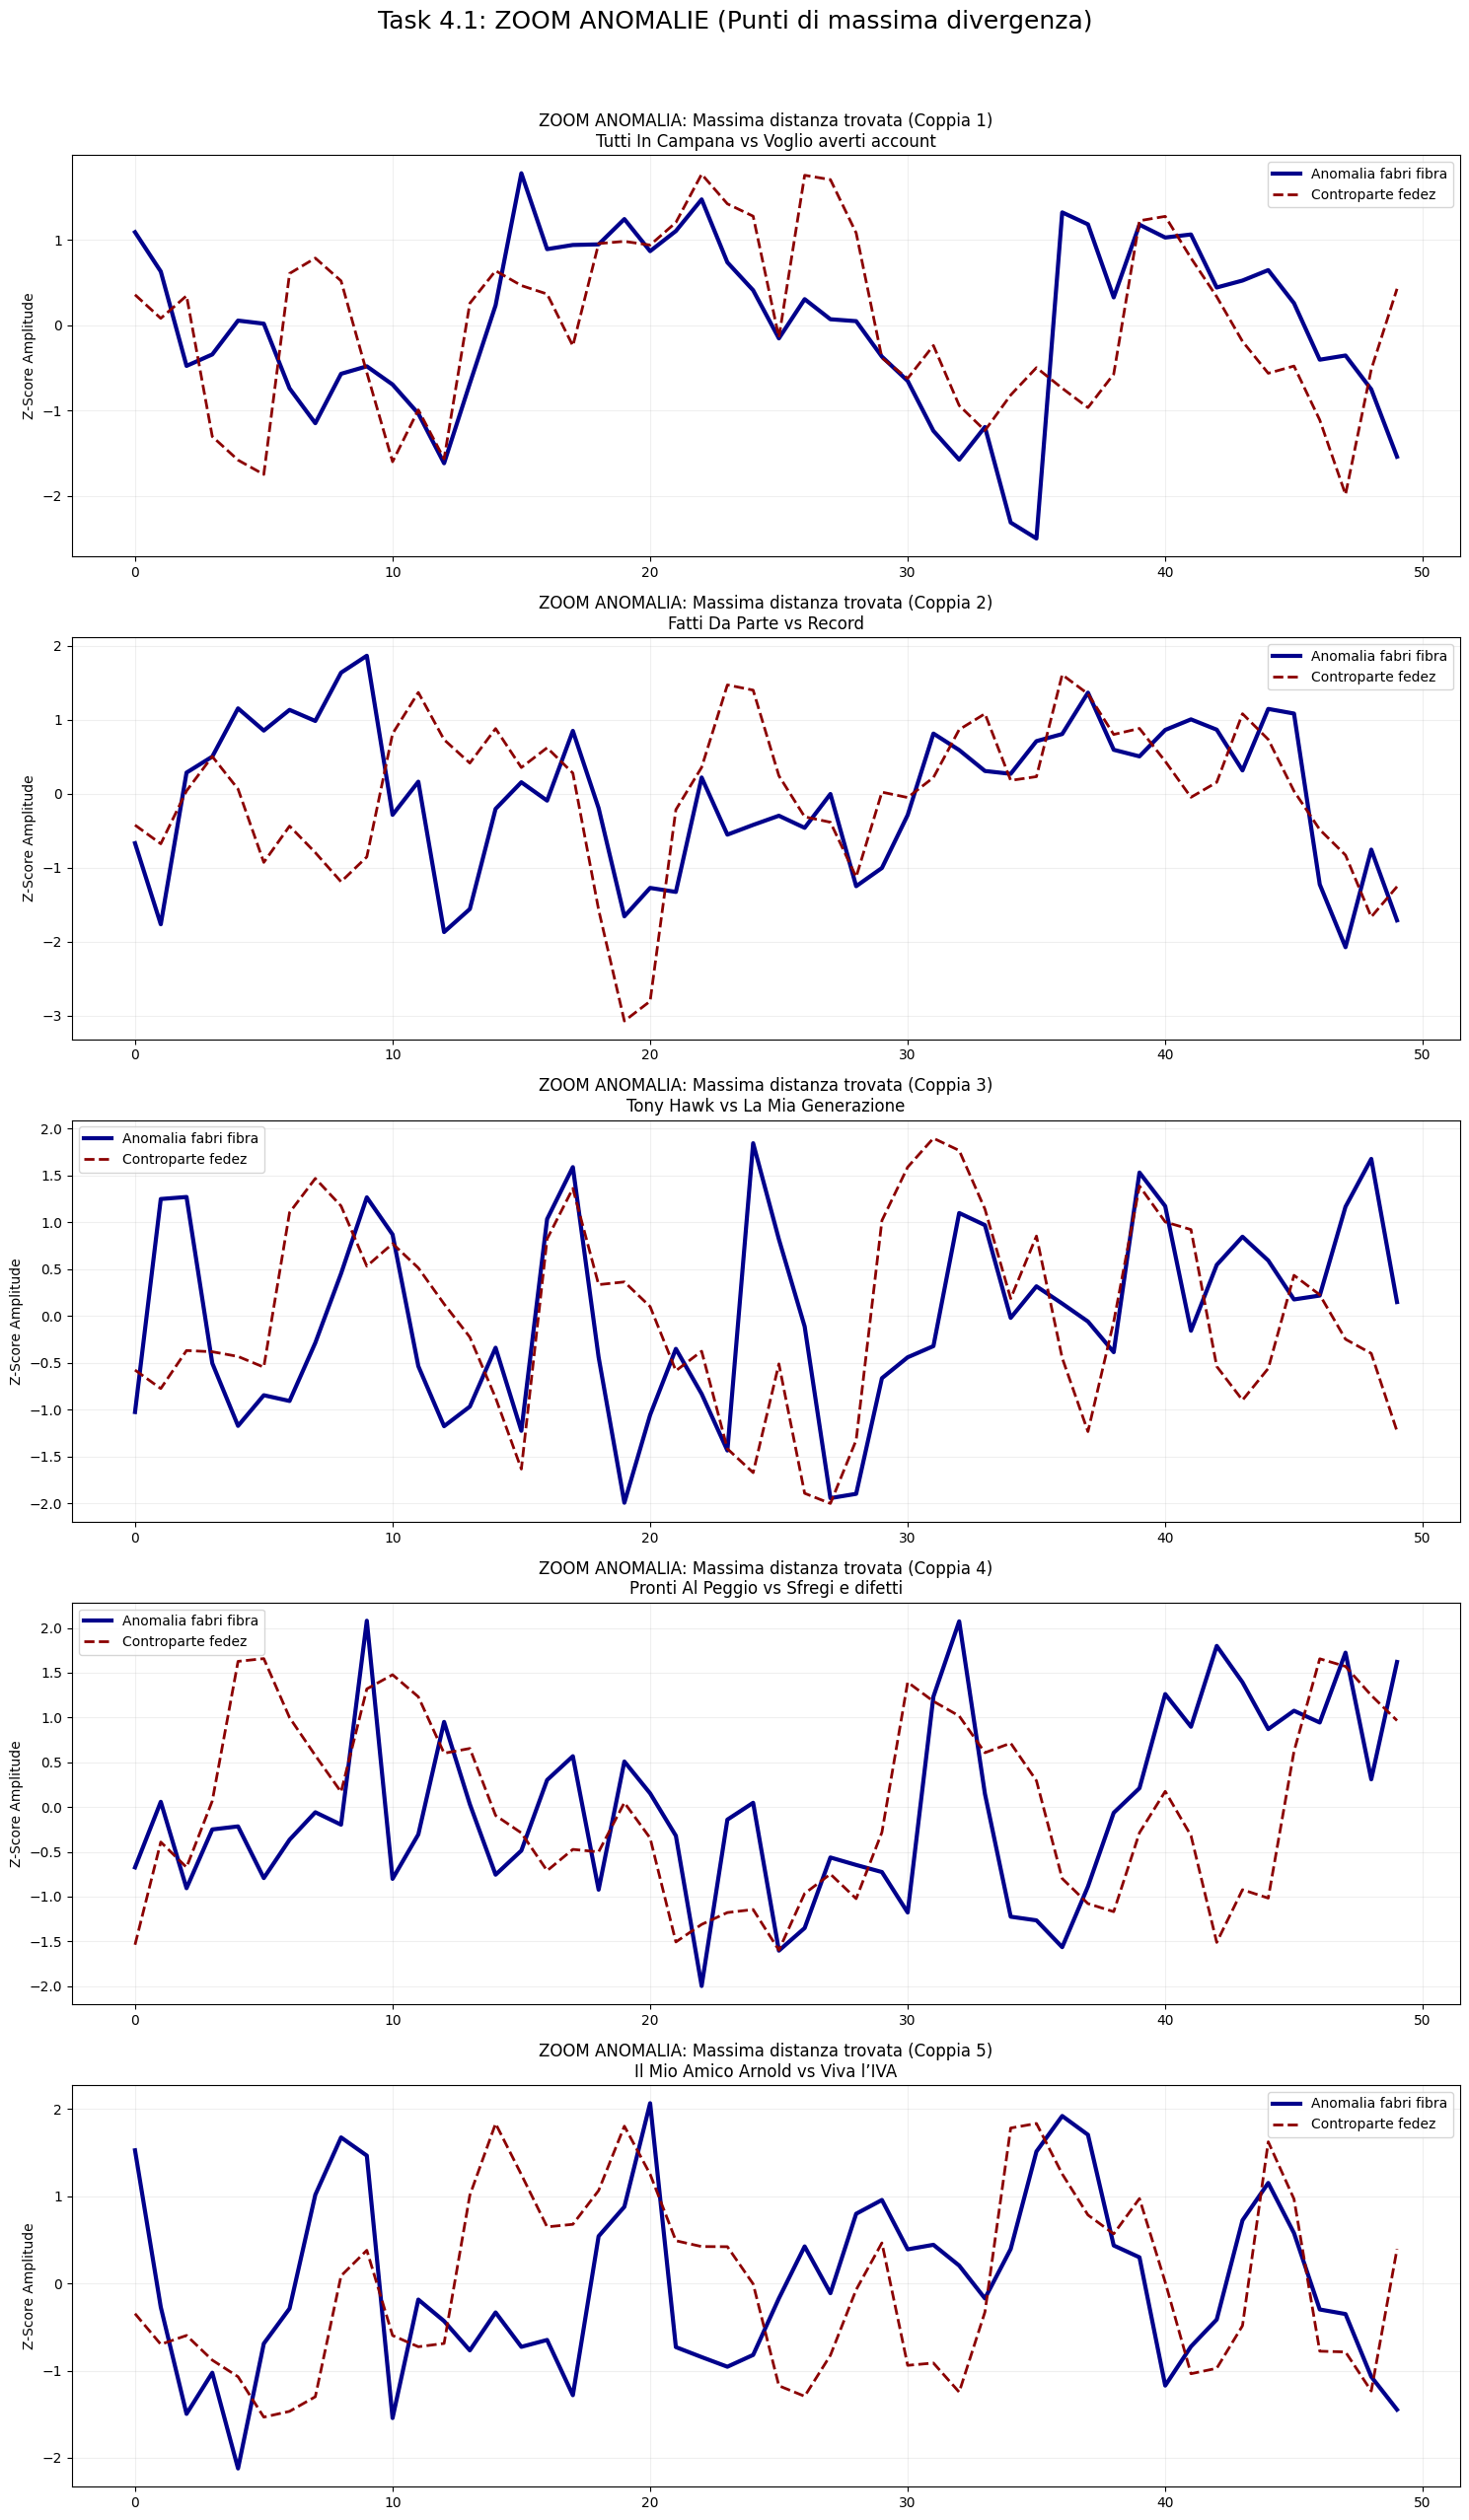

In [51]:
import stumpy
import numpy as np
import matplotlib.pyplot as plt

m = 50 # Finestra di circa 2 secondi

fig, axes = plt.subplots(5, 1, figsize=(15, 25))
fig.suptitle('Task 4.1: ZOOM ANOMALIE (Punti di massima divergenza)', fontsize=18, y=1.02)

for i, (index, row) in enumerate(df_cross.head(5).iterrows()):
    idx_a = np.where(df['track_id'].values == row['id_1'])[0][0]
    idx_b = np.where(df['track_id'].values == row['id_2'])[0][0]
    
    # Carichiamo le serie temporali medie
    s_a = X_final[idx_a, :, :].mean(axis=1).flatten().astype(float)
    s_b = X_final[idx_b, :, :].mean(axis=1).flatten().astype(float)
    
    # Usiamo lo STUMP AB-join: calcola la distanza di ogni pezzetto di A rispetto a B
    comp_mp = stumpy.stump(s_a, m=m, T_B=s_b)
    
    # L'ANOMALIA CROSS-ARTIST è il punto dove la distanza è MASSIMA (argmax)
    # Ovvero il pezzetto di Fedez che meno somiglia a qualsiasi pezzetto di Fibra
    idx_a_discord = np.argmax(comp_mp[:, 0])
    # Troviamo comunque il punto "meno lontano" in B per il confronto visivo
    idx_b_nearest = comp_mp[idx_a_discord, 1]
    
    # Estrazione segmenti
    seg_a = s_a[idx_a_discord : idx_a_discord + m]
    seg_b = s_b[idx_b_nearest : idx_b_nearest + m]
    
    # Normalizzazione per confrontare il profilo (forma)
    seg_a_norm = (seg_a - np.mean(seg_a)) / np.std(seg_a)
    seg_b_norm = (seg_b - np.mean(seg_b)) / np.std(seg_b)
    
    ax = axes[i]
    ax.plot(seg_a_norm, label=f"Anomalia {row['artist_1']}", lw=3, color='darkblue')
    ax.plot(seg_b_norm, label=f"Controparte {row['artist_2']}", lw=2, color='darkred', linestyle='--')
    
    ax.set_title(f"ZOOM ANOMALIA: Massima distanza trovata (Coppia {i+1})\n{row['song_1']} vs {row['song_2']}")
    ax.set_ylabel("Z-Score Amplitude")
    ax.legend()
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Shapelet Analysis

In [52]:
from tslearn.shapelets import LearningShapelets
from tslearn.utils import to_time_series_dataset

# 1. Prepariamo il dataset (tslearn vuole un formato specifico)
# Usiamo X_final che contiene le tue serie temporali 500x13
X_shape = to_time_series_dataset(X_final)
y_shape = y_true # 0 per Fedez, 1 per Fibra

# 2. Configuriamo il modello
# Cerchiamo 1 shapelet di lunghezza 50 (circa 2-3 secondi di audio)
n_shapelets = 1
shapelet_length = 50
lpdtw = LearningShapelets(n_shapelets_per_size={shapelet_length: n_shapelets},
                          max_iter=100,
                          verbose=0,
                          random_state=42)

# 3. Addestramento (il modello "impara" la forma distintiva)
print("Estrazione della Shapelet in corso... potrebbe richiedere un momento.")
lpdtw.fit(X_shape, y_shape)

# 4. Recuperiamo la Shapelet imparata
# È una forma che rappresenta il "confine" tra i due artisti
shapelet_distintiva = lpdtw.shapelets_[0].flatten()

Estrazione della Shapelet in corso... potrebbe richiedere un momento.


d:\Anaconda\envs\mining_env\Lib\site-packages\tslearn\shapelets\shapelets.py:492: FutureWarning: The default value for 'scale' is set to False in version 0.4 to ensure backward compatibility, but is likely to change in a future version.
  warnings.warn("The default value for 'scale' is set to False "
d:\Anaconda\envs\mining_env\Lib\site-packages\keras\src\layers\layer.py:982: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


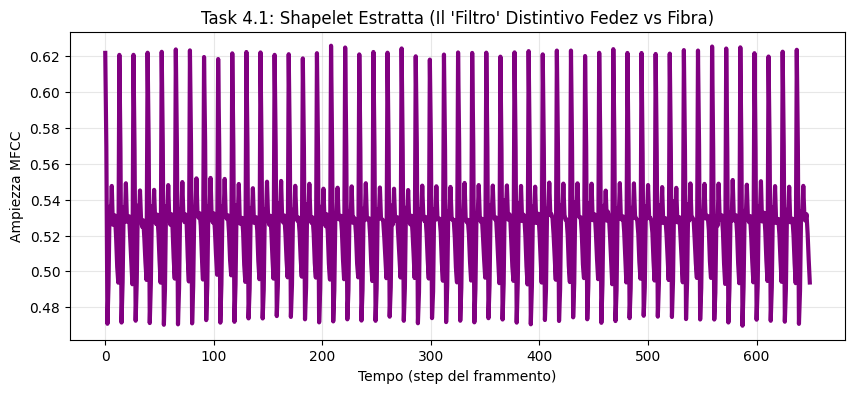

In [53]:
plt.figure(figsize=(10, 4))
plt.plot(shapelet_distintiva, color='purple', lw=3)
plt.title("Task 4.1: Shapelet Estratta (Il 'Filtro' Distintivo Fedez vs Fibra)")
plt.xlabel("Tempo (step del frammento)")
plt.ylabel("Ampiezza MFCC")
plt.grid(True, alpha=0.3)
plt.show()

## Multishapelet extraction

In [54]:
from tslearn.shapelets import LearningShapelets

# Definiamo diverse scale temporali: 25 step (~1s) e 100 step (~4s)
shapelet_sizes = {25: 2, 100: 1} 

ls = LearningShapelets(n_shapelets_per_size=shapelet_sizes,
                       max_iter=100,
                       random_state=42,
                       verbose=0)

ls.fit(X_shape, y_shape)

# Ora abbiamo 3 shapelets totali (2 corte, 1 lunga)
shapelets = ls.shapelets_

d:\Anaconda\envs\mining_env\Lib\site-packages\tslearn\shapelets\shapelets.py:492: FutureWarning: The default value for 'scale' is set to False in version 0.4 to ensure backward compatibility, but is likely to change in a future version.
  warnings.warn("The default value for 'scale' is set to False "
d:\Anaconda\envs\mining_env\Lib\site-packages\keras\src\layers\layer.py:982: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
d:\Anaconda\envs\mining_env\Lib\site-packages\keras\src\layers\layer.py:982: UserWarning: Layer 'min_pooling_1' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
d:\Anaconda\envs

## Probability distribution analysis

### La vera analisi profonda consiste nel vedere quanto una canzone è "vicina" alla Shapelet di Fedez o a quella di Fibra. Questo trasforma una forma d'onda in un punteggio di probabilità

d:\Anaconda\envs\mining_env\Lib\site-packages\keras\src\layers\layer.py:982: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
d:\Anaconda\envs\mining_env\Lib\site-packages\keras\src\layers\layer.py:982: UserWarning: Layer 'min_pooling_1' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


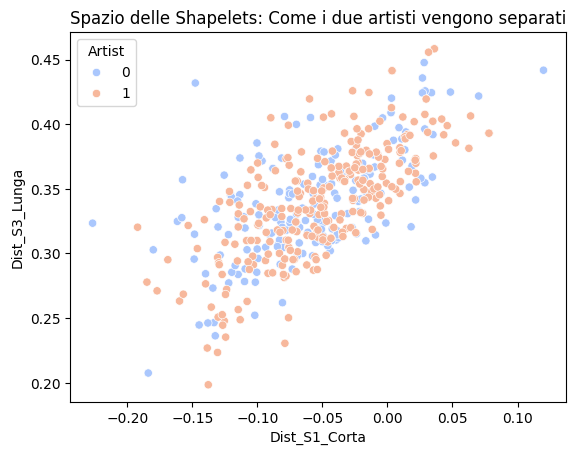

In [55]:
# Trasformiamo le serie temporali nello spazio delle distanze dalle shapelet
X_distances = ls.transform(X_shape)

# Creiamo un DataFrame per l'analisi
df_dist = pd.DataFrame(X_distances, columns=['Dist_S1_Corta', 'Dist_S2_Corta', 'Dist_S3_Lunga'])
df_dist['Artist'] = y_true # 0: Fedez, 1: Fibra

# Visualizziamo come le Shapelet separano i due artisti
sns.scatterplot(data=df_dist, x='Dist_S1_Corta', y='Dist_S3_Lunga', hue='Artist', palette='coolwarm')
plt.title("Spazio delle Shapelets: Come i due artisti vengono separati")
plt.show()

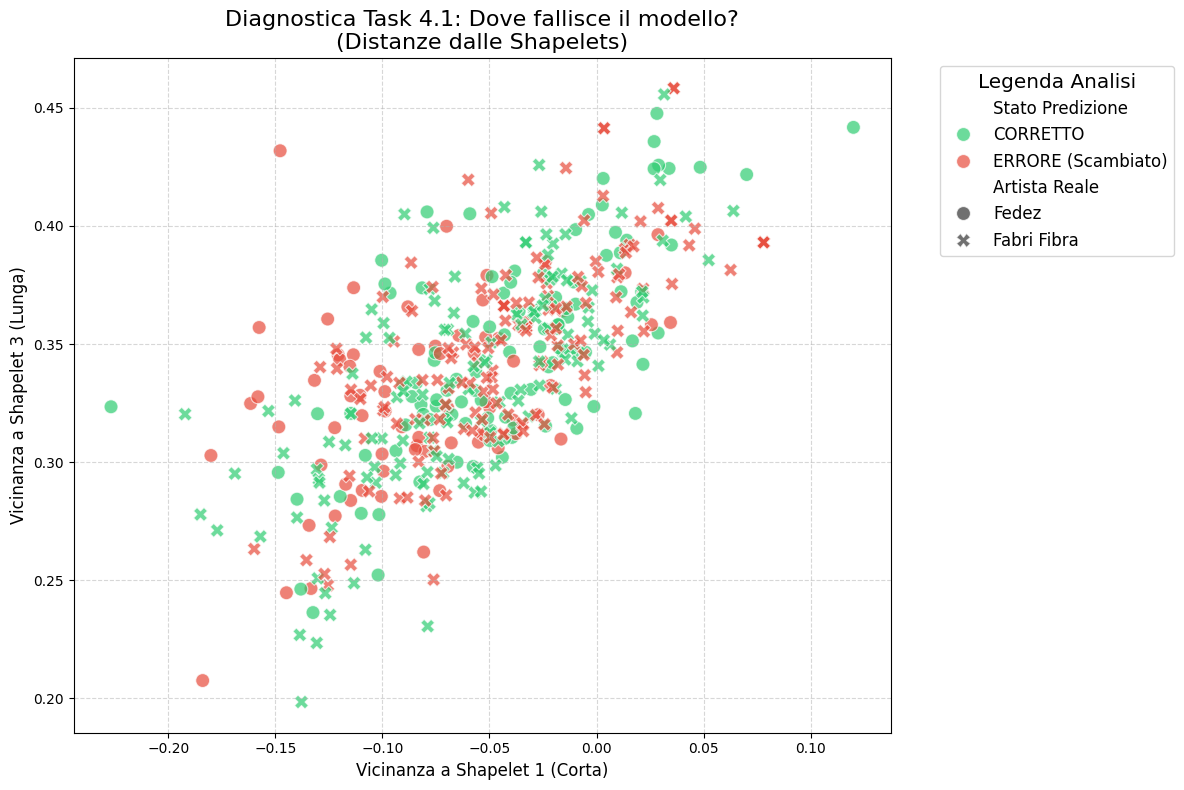

In [88]:
# Creiamo una colonna descrittiva per la legenda
df_dist['Stato Predizione'] = df_dist['Is_Error'].map({True: 'ERRORE (Scambiato)', False: 'CORRETTO'})
df_dist['Artista Reale'] = df_dist['Artist'].map({0: 'Fedez', 1: 'Fabri Fibra'})

plt.figure(figsize=(12, 8))

# Usiamo una palette molto contrastata: Rosso per l'errore, Verde per il corretto
palette_colori = {'ERRORE (Scambiato)': '#e74c3c', 'CORRETTO': '#2ecc71'}

sns.scatterplot(
    data=df_dist, 
    x='Dist_S1_Corta', 
    y='Dist_S3_Lunga', 
    hue='Stato Predizione',   # Il colore dice se il modello ha sbagliato
    style='Artista Reale',    # La forma (cerchio/croce) dice chi è l'autore
    palette=palette_colori,
    s=100,                    # Punti più grandi per vederli meglio
    alpha=0.7,
    edgecolor='w'
)

# Spostiamo la legenda fuori dal grafico per non coprire i punti
plt.legend(title='Legenda Analisi', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='large', title_fontsize='x-large')

plt.title("Diagnostica Task 4.1: Dove fallisce il modello?\n(Distanze dalle Shapelets)", fontsize=16)
plt.xlabel("Vicinanza a Shapelet 1 (Corta)", fontsize=12)
plt.ylabel("Vicinanza a Shapelet 3 (Lunga)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Analisi "Localizzativa": Dove appare la Shapelet?
### Questa è la parte più descrittiva: prendiamo una canzone dove il modello ha sbagliato e cerchiamo se la "Shapelet di Fibra" appare comunque, traendo in inganno il sistema.

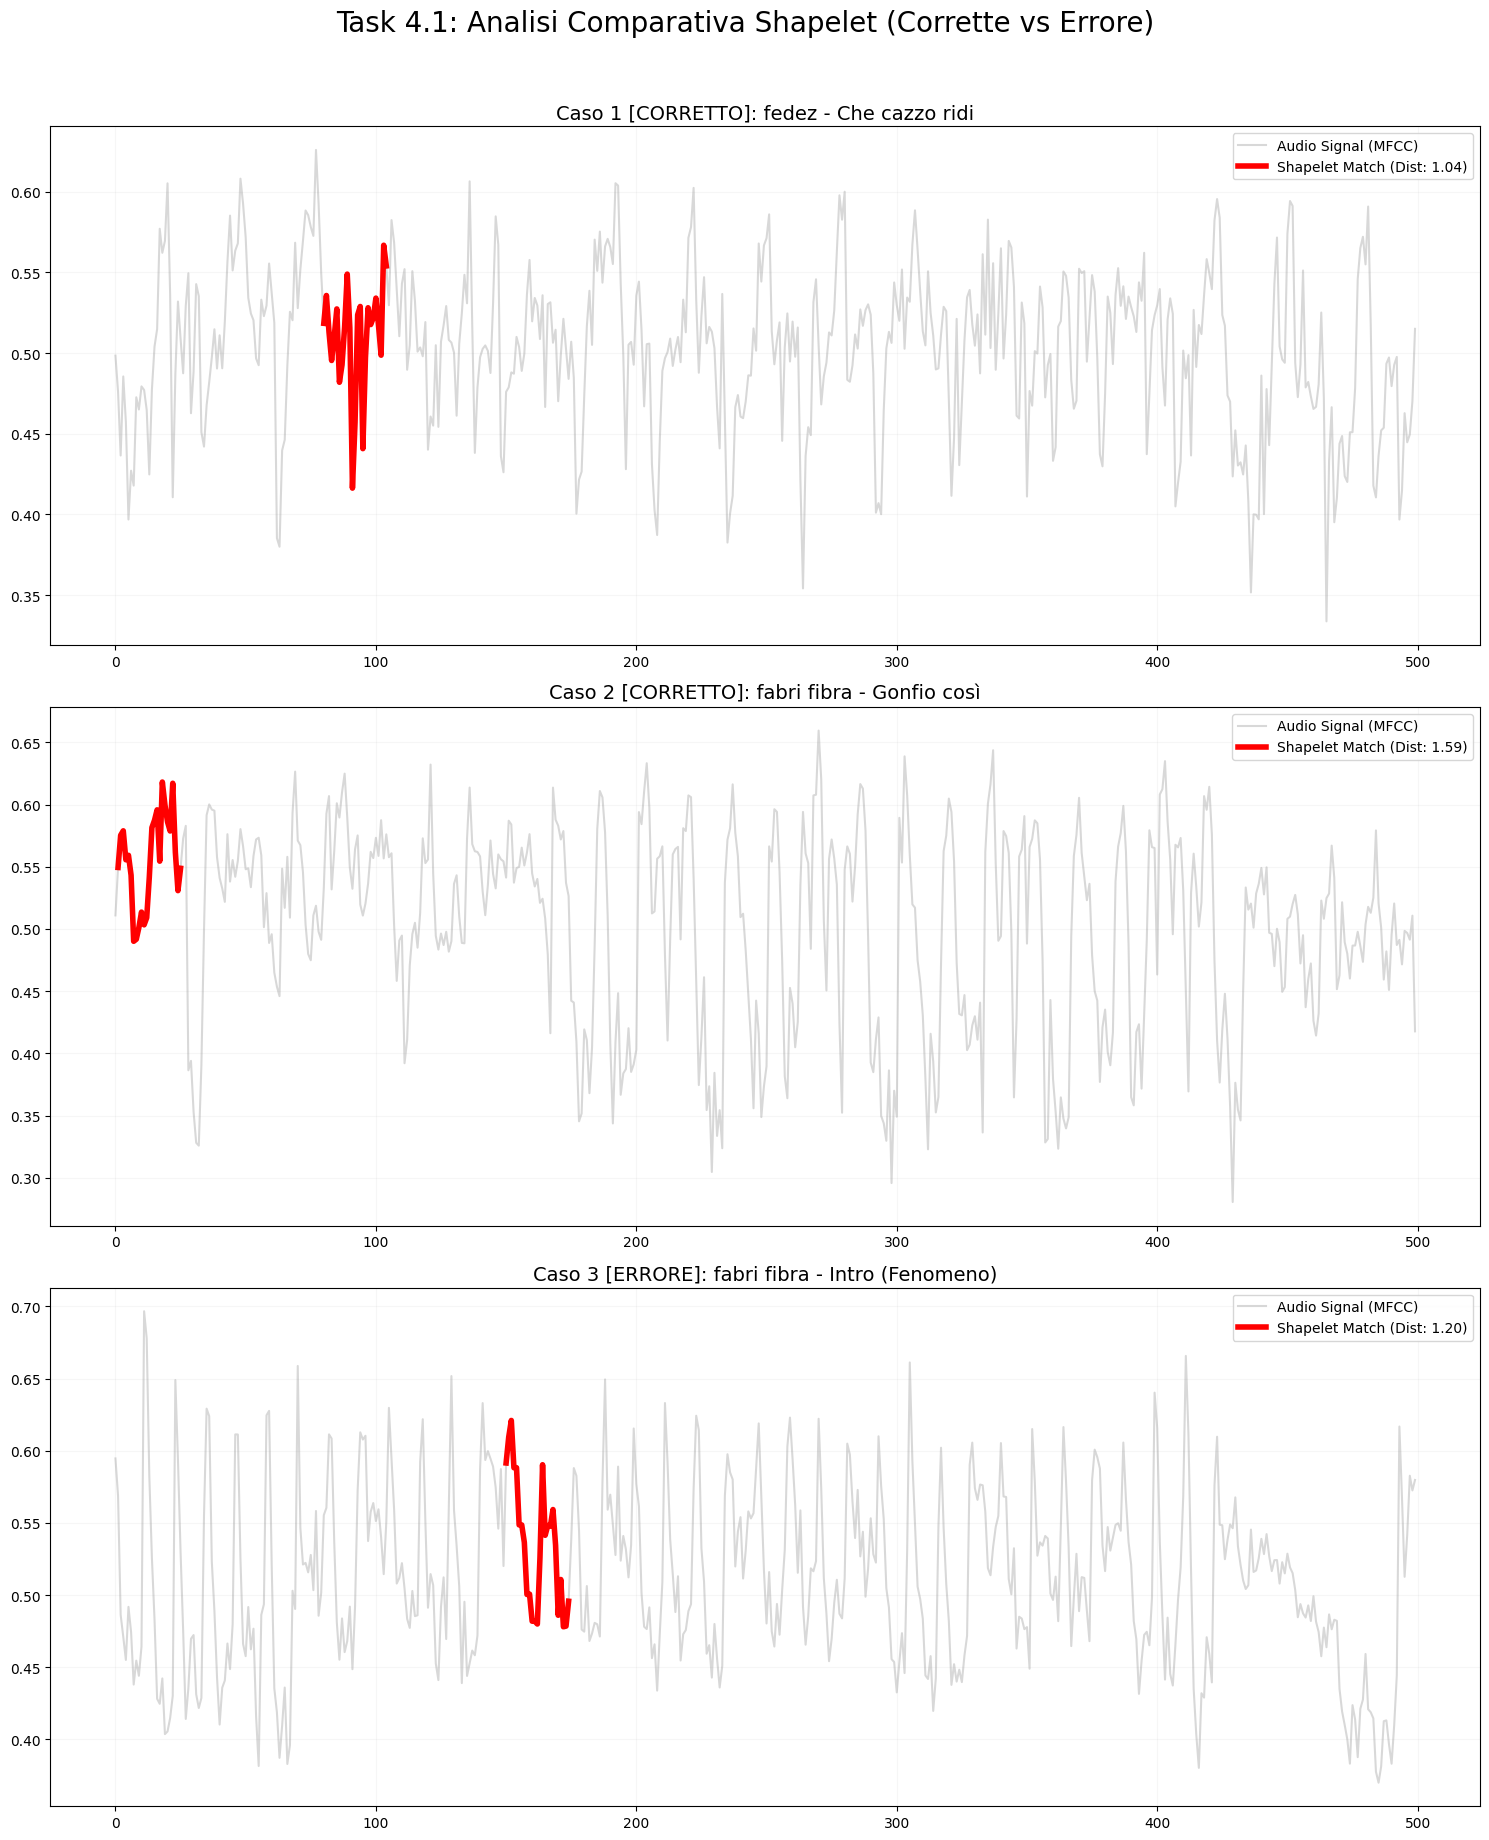

In [56]:
import numpy as np
import matplotlib.pyplot as plt

def get_best_shapelet_match(idx_song, shapelet):
    ts = X_final[idx_song, :, :].mean(axis=1).flatten().astype(float)
    s = shapelet.flatten()
    # Calcolo distanza sliding window
    distances = [np.linalg.norm(ts[i:i+len(s)] - s) for i in range(len(ts)-len(s))]
    return ts, np.argmin(distances), np.min(distances)

# 1. Identifichiamo i tre casi (cambia gli indici se necessario)
# Caso A: Un Fedez predetto correttamente (non deve essere negli error_tr_codes)
id_fedez_ok = df[(df['name_artist'] == 'fedez') & (~df['track_id'].isin(error_tr_codes))]['track_id'].iloc[0]

# Caso B: Un Fibra predetto correttamente
id_fibra_ok = df[(df['name_artist'] == 'fabri fibra') & (~df['track_id'].isin(error_tr_codes))]['track_id'].iloc[0]

# Caso C: L'errore puro che abbiamo isolato prima
id_errore = errori_puri_ids[0]

casi = [id_fedez_ok, id_fibra_ok, id_errore]
shapelet_da_testare = shapelets[0] # La prima shapelet imparata

fig, axes = plt.subplots(3, 1, figsize=(15, 18))
fig.suptitle('Task 4.1: Analisi Comparativa Shapelet (Corrette vs Errore)', fontsize=20, y=1.02)

for i, track_id in enumerate(casi):
    idx = get_row_index(track_id)
    info = df.iloc[idx]
    ts, best_idx, dist = get_best_shapelet_match(idx, shapelet_da_testare)
    
    ax = axes[i]
    ax.plot(ts, color='gray', alpha=0.3, label='Audio Signal (MFCC)')
    # Evidenzio il match della shapelet
    ax.plot(range(best_idx, best_idx+len(shapelet_da_testare)), 
            ts[best_idx:best_idx+len(shapelet_da_testare)], 
            color='red', lw=4, label=f'Shapelet Match (Dist: {dist:.2f})')
    
    # Titolo dinamico
    tipo = "CORRETTO" if track_id not in error_tr_codes else "ERRORE"
    ax.set_title(f"Caso {i+1} [{tipo}]: {info['name_artist']} - {info['title']}", fontsize=14)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.1)

plt.tight_layout()
plt.show()

In [61]:
# Vediamo quanti errori ha fatto il modello per ogni artista
error_df = df[df['track_id'].isin(error_tr_codes)]
print("Distribuzione degli errori per artista reale:")
print(error_df['name_artist'].value_counts())

Distribuzione degli errori per artista reale:
name_artist
fabri fibra    142
fedez           69
Name: count, dtype: int64


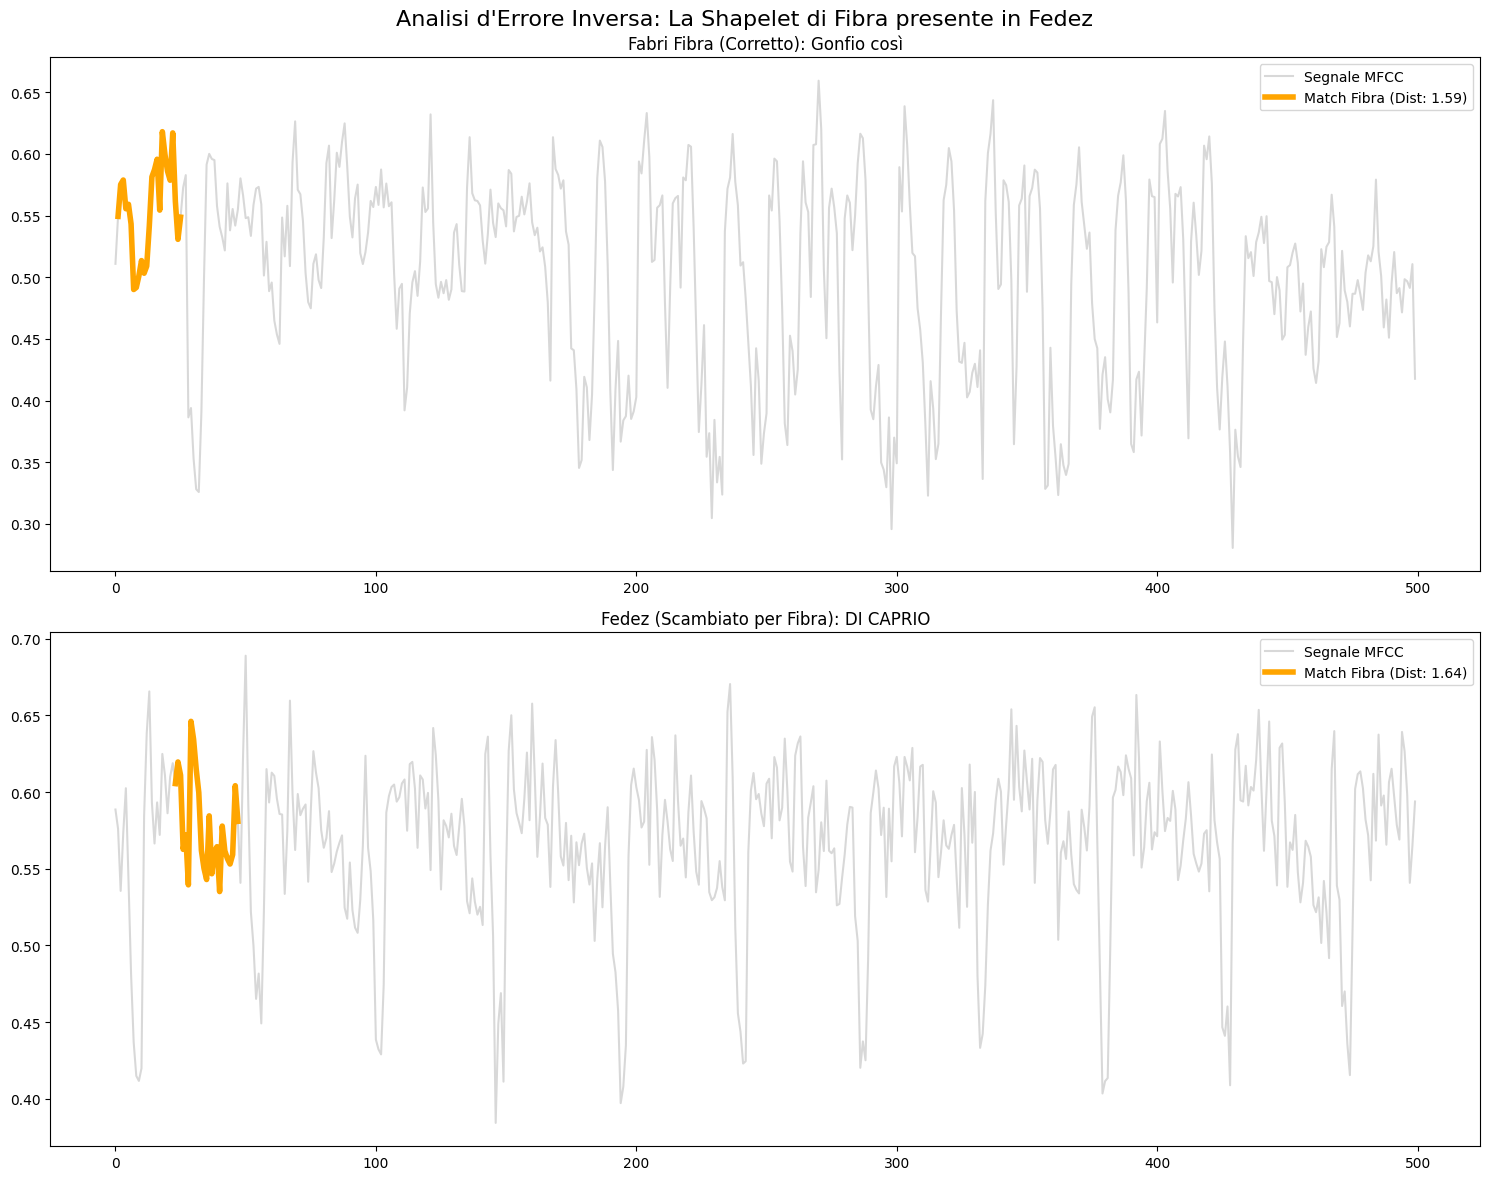

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Troviamo una Shapelet specifica per Fabri Fibra (Classe 1)
# Calcoliamo la distanza media di ogni shapelet dai brani di Fibra (y=1)
X_distances = ls.transform(X_shape)
mean_dist_fibra = X_distances[y_true == 1].mean(axis=0)
best_shapelet_idx_fibra = np.argmin(mean_dist_fibra)
shapelet_fibra = ls.shapelets_[best_shapelet_idx_fibra]

# 2. Selezioniamo i due casi per il confronto inverso
# Caso A: Fabri Fibra riconosciuto correttamente
id_fibra_ok = df[(df['name_artist'] == 'fabri fibra') & (~df['track_id'].isin(error_tr_codes))]['track_id'].iloc[0]

# Caso B: Fedez riconosciuto ERRONEAMENTE come Fibra
# Cerchiamo un brano dove l'artista reale è Fedez ma il modello ha fallito assegnandolo a Fibra
id_fedez_scambiato = df[(df['name_artist'] == 'fedez') & (df['track_id'].isin(error_tr_codes))]['track_id'].iloc[0]

casi_confronto_inv = [id_fibra_ok, id_fedez_scambiato]
titles_inv = ["Fabri Fibra (Corretto)", "Fedez (Scambiato per Fibra)"]

fig, axes = plt.subplots(2, 1, figsize=(15, 12))
fig.suptitle('Analisi d\'Errore Inversa: La Shapelet di Fibra presente in Fedez', fontsize=16)

for i, track_id in enumerate(casi_confronto_inv):
    idx = get_row_index(track_id)
    ts, best_idx, dist = get_best_shapelet_match(idx, shapelet_fibra)
    
    # ESTRAIAMO IL SEGMENTO PER NORMALIZZARLO (Z-Score)
    segmento = ts[best_idx:best_idx+len(shapelet_fibra)]
    # (segmento - media) / deviazione standard per vedere la FORMA pura
    seg_norm = (segmento - np.mean(segmento)) / (np.std(segmento) + 1e-8)
    sha_norm = (shapelet_fibra.flatten() - np.mean(shapelet_fibra)) / (np.std(shapelet_fibra) + 1e-8)

    ax = axes[i]
    # Plottiamo il segnale originale in sottofondo
    ax.plot(ts, color='gray', alpha=0.3, label='Segnale MFCC')
    
    # Evidenziamo il match
    ax.plot(range(best_idx, best_idx+len(shapelet_fibra)), 
            ts[best_idx:best_idx+len(shapelet_fibra)], 
            color='orange', lw=4, label=f'Match Fibra (Dist: {dist:.2f})')
    
    ax.set_title(f"{titles_inv[i]}: {df.iloc[idx]['title']}")
    ax.legend()
plt.tight_layout()
plt.show()

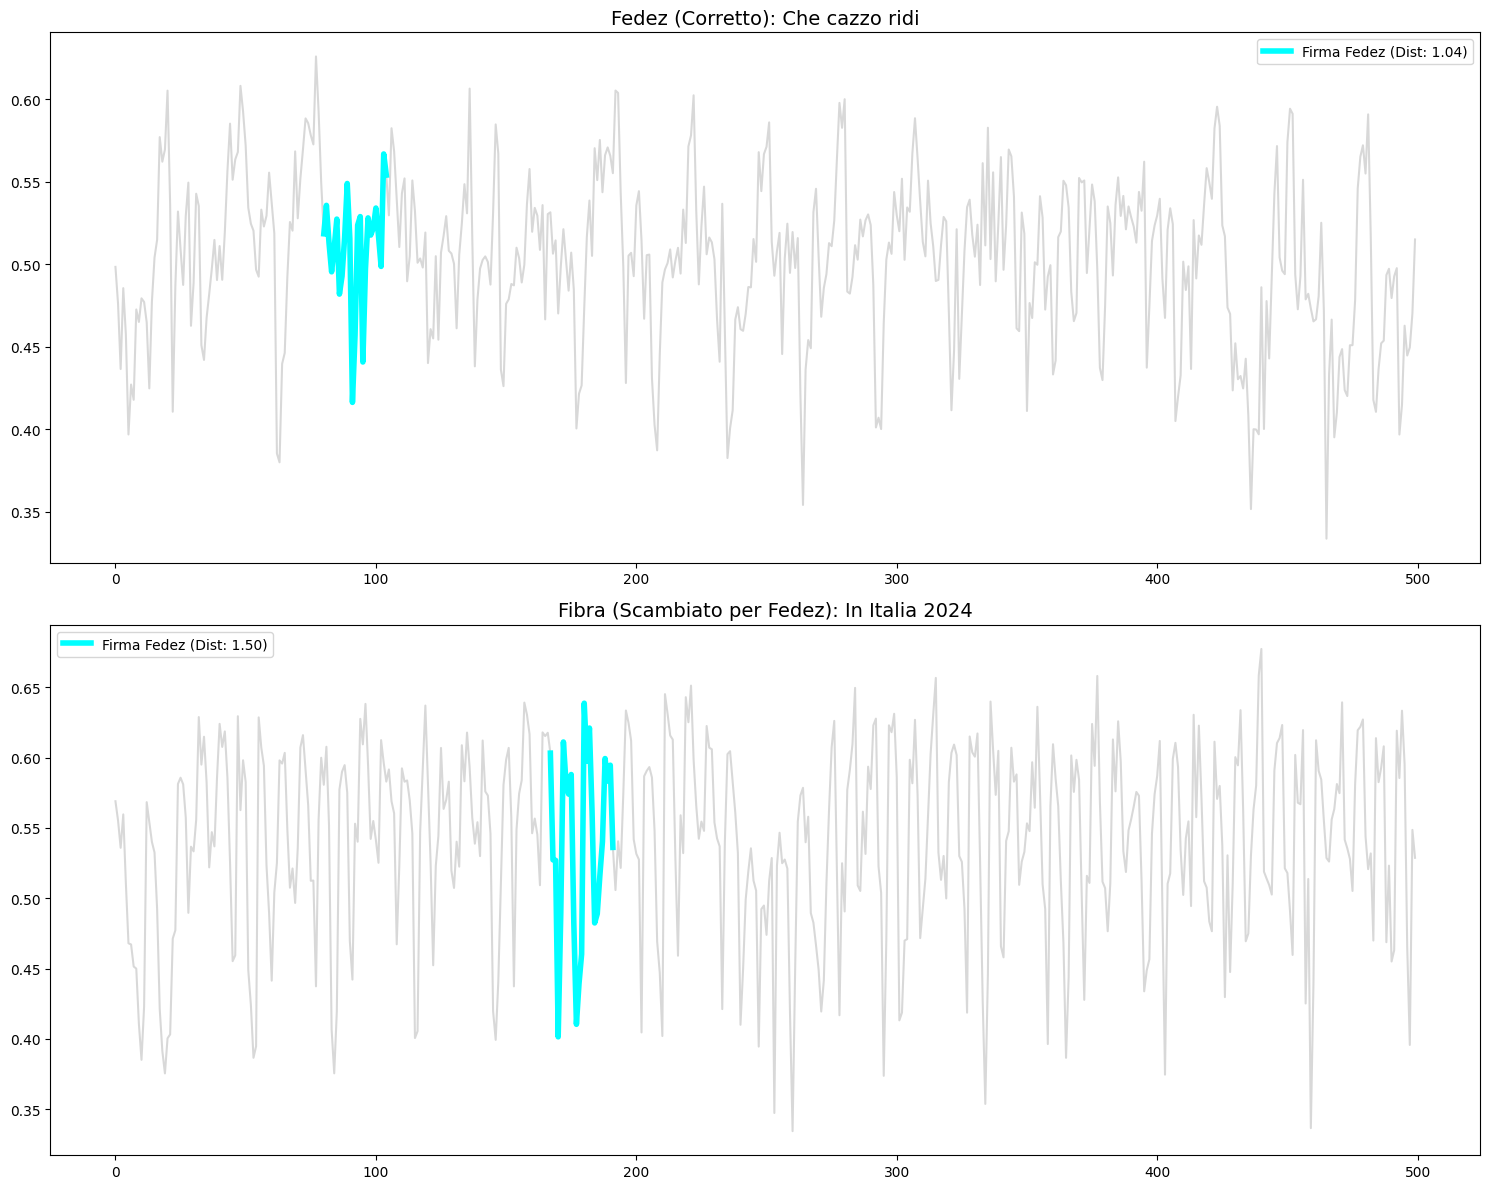

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# 1. IDENTIFICAZIONE COMPLETA ERRORI (Fibra -> Fedez E Fedez -> Fibra)
idx_fibra_as_fedez = np.where((y_true == 1) & (y_pred == 0))[0]
idx_fedez_as_fibra = np.where((y_true == 0) & (y_pred == 1))[0]

error_tr_codes = [names[i].split(' - ')[-1].replace('.mp3', '') for i in np.concatenate([idx_fibra_as_fedez, idx_fedez_as_fibra])]

# 2. SELEZIONE SHAPELET DISCRIMINANTE PER FEDEZ
# Cerchiamo la shapelet che minimizza la distanza dai brani di Fedez (classe 0)
# X_distances ha dimensioni (n_samples, n_shapelets)
X_distances = ls.transform(X_shape)
dist_fedez = X_distances[y_true == 0].mean(axis=0)
dist_fibra = X_distances[y_true == 1].mean(axis=0)

# La migliore shapelet per Fedez è quella che è vicina a lui ma LONTANA da Fibra
best_shapelet_idx = np.argmin(dist_fedez - dist_fibra) 
shapelet_fedez = ls.shapelets_[best_shapelet_idx]

# 3. PREPARAZIONE CONFRONTO (Errore vs Corretto)
# Prendiamo un Fedez OK e un Fibra scambiato per Fedez
id_fedez_ok = df[(df['name_artist'].str.lower() == 'fedez') & (~df['track_id'].isin(error_tr_codes))]['track_id'].iloc[0]
id_fibra_err = names[idx_fibra_as_fedez[0]].split(' - ')[-1].replace('.mp3', '')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

for ax, t_id, title in zip([ax1, ax2], [id_fedez_ok, id_fibra_err], ["Fedez (Corretto)", "Fibra (Scambiato per Fedez)"]):
    idx = get_row_index(t_id)
    ts, b_idx, d = get_best_shapelet_match(idx, shapelet_fedez)
    
    ax.plot(ts, color='gray', alpha=0.3)
    ax.plot(range(b_idx, b_idx+len(shapelet_fedez)), ts[b_idx:b_idx+len(shapelet_fedez)], 
            color='cyan', lw=4, label=f'Firma Fedez (Dist: {d:.2f})')
    ax.set_title(f"{title}: {df.iloc[idx]['title']}", fontsize=14)
    ax.legend()

plt.tight_layout()
plt.show()